# Odległość od Central Business District
Zakładając najprostszy możliwy sposób liczenia, czyli trochę arbitralnie wybrany konkretny punkt i odległość do niego w linii prostej

### Dodanie zmiennej określającej odległość

In [ ]:
# Gemini mi poradził, żeby też tutaj zainstalować Pandas, bo wcześniej nie działało

%pip install pandas

  Using cached pandas-3.0.5-cp314-cp314-win_amd64.whl.metadata (19 kB)
  Using cached numpy-2.5.3-cp314-cp314-win_amd64.whl.metadata (6.6 kB)
  Using cached tzdata-2026.3-py2.py3-none-any.whl.metadata (1.4 kB)
Using cached pandas-3.0.5-cp314-cp314-win_amd64.whl (10.0 MB)
Using cached numpy-2.5.3-cp314-cp314-win_amd64.whl (12.7 MB)
Using cached tzdata-2026.3-py2.py3-none-any.whl (348 kB)

   ---------------------------------------- 0/3 [tzdata]
   ---------------------------------------- 0/3 [tzdata]
   ---------------------------------------- 0/3 [tzdata]
   ------------- -------------------------- 1/3 [numpy]
   ------------- -------------------------- 1/3 [numpy]
   ------------- -------------------------- 1/3 [numpy]
   ------------- -------------------------- 1/3 [numpy]
   ------------- -------------------------- 1/3 [numpy]
   ------------- -------------------------- 1/3 [numpy]
   ------------- -------------------------- 1/3 [numpy]
   ------------- -------------------------- 1/

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [3]:
# Wczytanie danych
import pandas as pd
import numpy as np
data = pd.read_csv(r"dane\warszawa_lokale.csv")
data['creation_date'] = pd.to_datetime(data['creation_date'])

In [ ]:
#Tutaj jest główny kod do obliczania odległości od CBD (Central Business District) w Warszawie, który wykorzystuje funkcję Haversine'a do obliczenia odległości między dwoma punktami geograficznymi na powierzchni Ziemi.

# 1. Definicja zwektoryzowanej funkcji
def odleglosc_punktow(p1, p2):
    # p1 i p2 to tablice/listy typu [szerokosc, dlugosc]
    p1 = np.array(p1)
    p2 = np.array(p2)

    K = 111.32  # Stała przelicznikowa dla stopni na kilometry (średnia wartość)
    
    # 1. Zwykła różnica współrzędnych pomnożona przez stałą K
    roznica = (p1 - p2) * K
    
    # 2. Korekta dla długości geograficznej (indeks 1 to długość)
    # Używamy średniej szerokości geograficznej obu punktów lub punktu startowego
    roznica[1] *= np.cos(np.radians(p1[0])) 
    
    # 3. Twierdzenie Pitagorasa: pierwiastek z sumy kwadratów różnic
    odleglosc = np.sqrt((roznica ** 2).sum())
    
    return round(odleglosc, 0)



# 2. Zdefiniowanie punktu CBD

rondo_onz = np.array([52.2331227, 20.9983505])
rondo_daszynskiego = np.array([52.2303181, 20.9844480])
rondo_dmowskiego = np.array([52.2298297, 21.0117312])
pkin = np.array([52.2256658, 21.0038333])
dworzec_centralny = np.array([52.22882, 21.00287])

cbd = rondo_onz  # Możesz zmienić na inny punkt, np. rondo_daszynskiego, rondo_dmowskiego, pkin, dworzec_centralny



# 3. Obliczenie odległości i przypisanie do nowej kolumny
lokalizacja = np.array([data['latitude'], data['longitude']])
# Dopasowanie wymiarów punktu CBD do tablicy wielu lokalizacji
data['distance_to_cbd_km'] = odleglosc_punktow(
    lokalizacja,
    cbd[:, np.newaxis]
)

data[['name', 'latitude', 'longitude', 'distance_to_cbd_km']]

ValueError: operands could not be broadcast together with shapes (2,229727) (2,) 

### Podstawowe sprawdzenie, czy zwracane wyniki mają sens.
Wstępnie, patrząc na mapę, to wygląda sensownie.

In [ ]:
# Znalezienie rekordu z NAJMNIEJSZĄ odległością (najbliżej CBD)
najblizsza_nieruchomosc = data.loc[data['distance_to_cbd_km'].idxmin()]

# Znalezienie rekordu z NAJWIĘKSZĄ odległością (najdalej od CBD)
najdalsza_nieruchomosc = data.loc[data['distance_to_cbd_km'].idxmax()]

# Wyświetlenie wyników
print("=== Nieruchomość NAJBLIŻEJ centrum ===")
print(najblizsza_nieruchomosc[['name', 'latitude', 'longitude', 'distance_to_cbd_km']])
print("\n" + "="*38 + "\n") # Oddzielenie wyników
print("=== Nieruchomość NAJDALEJ od centrum ===")
print(najdalsza_nieruchomosc[['name', 'latitude', 'longitude', 'distance_to_cbd_km']])

=== Nieruchomość NAJBLIŻEJ centrum ===
name                  Aleja Jana Pawła II 18
latitude                           52.233813
longitude                          20.998791
distance_to_cbd_km                  0.082431
Name: 211618, dtype: object


=== Nieruchomość NAJDALEJ od centrum ===
name                  Ulica Podkowy 120P/1
latitude                         52.170439
longitude                        21.247732
distance_to_cbd_km               18.368958
Name: 215865, dtype: object


In [ ]:
print(data['distance_to_cbd_km'].describe())

count    229727.000000
mean          6.532479
std           3.266016
min           0.082431
25%           4.158939
50%           6.251378
75%           8.581850
max          18.368958
Name: distance_to_cbd_km, dtype: float64


### Wykres

In [ ]:
%pip install matplotlib

   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ------------------------ --------------- 5.8/9.5 MB 36.9 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 39.5 MB/s  0:00:00
   ---------------------------------------- 0.0/2.5 MB ? eta -:--:--
   ---------------------------------------- 2.5/2.5 MB 44.2 MB/s  0:00:00
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   ---------------------------------------- 7.2/7.2 MB 49.8 MB/s  0:00:00

   ---------------------------------------- 0/7 [pyparsing]
   ---------------------------------------- 0/7 [pyparsing]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ----------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


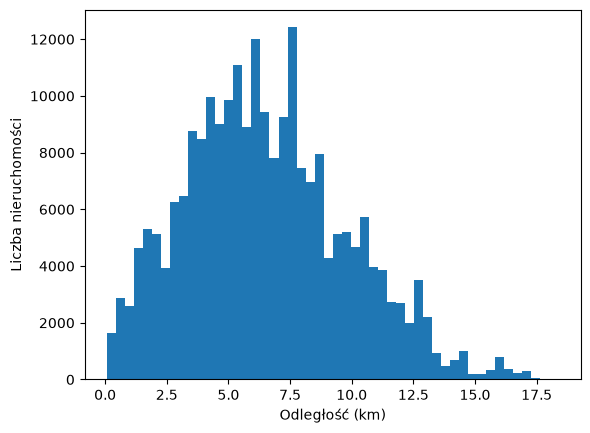

In [ ]:
# Wykres histogramu odległości do CBD
import matplotlib.pyplot as plt

data['distance_to_cbd_km'].plot(kind='hist', bins=50)

plt.xlabel('Odległość (km)')
plt.ylabel('Liczba nieruchomości')
plt.show()

Zastanawiam się, czy przez to, że wykres jest taki "poszarpany" nie będzie problemu z overfittingiem, jeśli na podstawie odległości rozpozna konkretne okolice, w których sprzedano dużo mieszkań.

### Nieruchomości bardzo daleko i bardzo blisko

In [ ]:
data[(data['distance_to_cbd_km'] > 17.5)]

,name,latitude,longitude,city,street,name.1,floor,rooms,size,amount,buyerType,sellerType,transactionType,marketType,participation,creation_date,classification,distance_to_cbd_km
215865,Ulica Podkowy 120P/1,52.170439,21.247732,Warszawa,Ulica Podkowy 120P/1,146514_8.1513.78_BUD.2_LOK,1.0,3,114.47,1209000.0,osobaFizyczna,osobaFizyczna,wolnyRynek,pierwotny,1/1,2024-09-03,transakcja,17.906166
215866,Ulica Podkowy 120P/1,52.170439,21.247732,Warszawa,Ulica Podkowy 120P/1,146514_8.1513.86/26.1_BUD.1_LOK,1.0,4,143.79,1359000.0,osobaFizyczna,osobaFizyczna,wolnyRynek,pierwotny,1/1,2024-04-23,transakcja,17.906166
229201,Ulica Podkowy 126D,52.172449,21.246826,Warszawa,Ulica Podkowy 126D,146514_8.1513.101_BUD.2_LOK,1.0,6,100.28,1100000.0,osobaFizyczna,osobaFizyczna,wolnyRynek,wtorny,1/1,2025-08-07,transakcja,17.768209


In [ ]:
data[(data['distance_to_cbd_km'] < 0.2)]

,name,latitude,longitude,city,street,name.1,floor,rooms,size,amount,buyerType,sellerType,transactionType,marketType,participation,creation_date,classification,distance_to_cbd_km
86758,Ulica Chmielna 98,52.229362,21.00014,Warszawa,Ulica Chmielna 98,146518_8.0110.29.1_BUD.36_LOK,9.0,3,32.75,340000.0,osobaFizyczna,osobaFizyczna,wolnyRynek,wtorny,1/1,2016-12-23,transakcja,0.195418
86759,Ulica Chmielna 98,52.229362,21.00014,Warszawa,Ulica Chmielna 98,146518_8.0110.6_BUD.7_LOK,6.0,4,52.44,810000.0,osobaFizyczna,osobaFizyczna,wolnyRynek,wtorny,1/1,2025-07-24,transakcja,0.195418
86760,Ulica Chmielna 98,52.229362,21.00014,Warszawa,Ulica Chmielna 98,146518_8.0110.29.1_BUD.23_LOK,5.0,4,52.70,660000.0,osobaFizyczna,osobaFizyczna,wolnyRynek,wtorny,1/1,2019-11-20,transakcja,0.195418
86761,Ulica Chmielna 98,52.229362,21.00014,Warszawa,Ulica Chmielna 98,146518_8.0110.29.1_BUD.25_LOK,5.0,4,53.80,520000.0,osobaFizyczna,osobaFizyczna,wolnyRynek,wtorny,1/1,2017-11-22,transakcja,0.195418
